In [1]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.9 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2025-03-11 12:09:56.981 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Accuracy: 0.40

              precision    recall  f1-score   support

           0       0.57      0.31      0.40        13
           1       0.31      0.57      0.40         7

    accuracy                           0.40        20
   macro avg       0.44      0.44      0.40        20
weighted avg       0.48      0.40      0.40        20



2025-03-11 12:09:57.460 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-03-11 12:09:57.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:09:57.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:09:57.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:09:57.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:09:57.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:09:57.710 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:09:58.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 

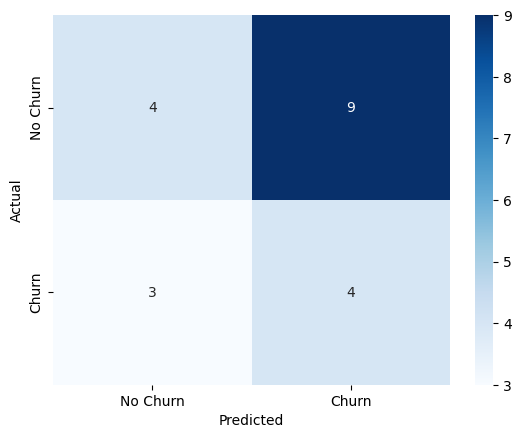

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import streamlit as st

# Load dataset
df = pd.read_csv('customer_churn_data.csv')  # Replace with actual dataset

# Preprocess data
df.dropna(inplace=True)  # Remove missing values

# Convert 'churn' column to integers
df['churn'] = df['churn'].astype(str).str.strip().map({'False': 0, 'True': 1})

# Convert categorical columns to numerical
df = pd.get_dummies(df, columns=['international_plan', 'voice_mail_plan'], drop_first=True)

# Drop unnecessary columns
df.drop(columns=['Id', 'state', 'phone_number'], inplace=True)

# Define features and target variable
X = df.drop(columns=['churn'])
y = df['churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}\n')
print(report)

# Streamlit app for visualization
st.title('Customer Churn Prediction')
st.write(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix Visualization
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
st.pyplot(fig)

# User input for prediction
st.sidebar.header('Predict Customer Churn')
features = {col: st.sidebar.number_input(f'Enter {col}:',
float(X[col].min()), float(X[col].max())) for col in X.columns}

if st.sidebar.button('Predict'):
    input_data = np.array([features[col] for col in X.columns]).reshape(1, - 1)
    prediction = model.predict(input_data)[0]
    st.sidebar.write(f'Predicted Churn: {"Yes" if prediction == 1 else"No"}')